In [10]:
from qutip import *
import matplotlib.pyplot as plt
from typing import Union
from qutip import basis
import jax.numpy as np
import qutip_jax
from scipy import integrate
import tqdm


In [11]:
#parameters
omega_r = 2 * np.pi * 50 #MHz
omega_max = omega_r
omega_R = 2.5 * omega_r #MHz
omega_c = omega_r #MHz
Dta = 2 * np.pi * 1200 #MHz
T_p = 16 * np.pi * Dta/(3 * omega_max**2)
T_c = np.pi/omega_r
tmax = T_c * 2 + T_p
V_dd = 2 * np.pi * 500 #MHz
V_vdws = 2 * np.pi * 1 #MHz
tau_c = 548
tau_p = 0.131
tau_R = 505
gamma_c = 1/tau_c
gamma_p = 1/tau_p
gamma_R = 1/tau_R

In [12]:
#time list
tlist = np.linspace(0, tmax, 1000)

with qutip.CoreOptions(default_dtype="jax"):
	#control atom states
	g = basis(2,0) #|0>     
	r = basis(2,1) #|1>

	#dagger
	g_dag = g.dag()  # <0|
	r_dag = r.dag()  # <1|

	#target atom states
	A = basis(4,0) 
	B = basis(4,1)
	P = basis(4,2)
	R = basis(4,3)

	#dagger
	A_dag = A.dag()
	B_dag = B.dag()
	P_dag = P.dag()
	R_dag = R.dag()

In [13]:
from qutip_jax.qobjevo import JaxJitCoeff

In [14]:
def Omega_c(t, omega_c, T_c, T_p, tmax):
    return (np.heaviside(T_c-t, 1) * omega_c + np.heaviside(t-T_c-T_p, 1) * omega_c * np.heaviside(tmax-t, 1))/2

In [15]:
omega_cc = JaxJitCoeff(Omega_c,args={
	"T_c":T_c,
	"omega_c":omega_c,
	"T_p":T_p,
	"tmax":tmax
}, static_argnames = ("omega_c","T_c", "T_p", "tmax",)) 

In [16]:
def Omega_p(t,  T_c, T_p, omega_max):
    return (np.heaviside(t-T_c,1) * np.heaviside(T_c+T_p-t,1) * omega_max * (np.sin(np.pi * (t-T_c)/T_p))**2)/2

In [17]:
omega_p = JaxJitCoeff(Omega_p,args={
	"T_c":T_c,
	"omega_max":omega_max,
	"T_p":T_p
}, static_argnames = ("omega_max","T_c", "T_p")) 

In [18]:
#integrate 
def integrand(t):
    return (2*Omega_p(t,T_c,T_p,omega_max))**2
integral_value, error = integrate.quad(integrand, 0, tmax)

print(f"积分值: {integral_value/(2 * np.pi * Dta):.6f}")
print(f"积分误差: {error:.2e}")


积分值: 1.000000
积分误差: 7.88e-06


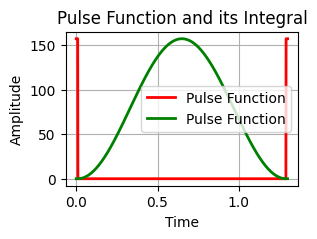

In [19]:
# 可视化函数和积分
t_plot = np.linspace(0, tmax, 1000)
pulse_valuesp = [Omega_p(t,T_c,T_p,omega_max) for t in t_plot]
pulse_valuesc = [Omega_c(t,omega_c,T_c,T_p,tmax) for t in t_plot]
#pulse_values = [Omega_c for t in t_plot]
plt.figure(figsize=(3, 2))
#plt.plot(t_plot, pulse_values, 'b-', linewidth=2, label='Pulse Function')
plt.plot(t_plot, pulse_valuesc, 'r-', linewidth=2, label='Pulse Function')
plt.plot(t_plot, pulse_valuesp, 'g-', linewidth=2, label='Pulse Function')

plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
hc_op = (g * r_dag + r * g_dag)
ht_op = P * A_dag + A * P_dag + P * B_dag + B * P_dag

hrr_op = r * r_dag
hRR_op = R * R_dag
ht_dta = - Dta * P * P_dag
ht_R = omega_R * (P * R_dag + R * P_dag)

Hc_op = tensor(hc_op, Qobj(np.eye(4)), Qobj(np.eye(4)))
Ht_op1 = tensor(Qobj(np.eye(2)), ht_op, Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), Qobj(np.eye(4)), ht_op)
Ht_R = tensor(Qobj(np.eye(2)), ht_R, Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), Qobj(np.eye(4)), ht_R)
Ht_dta = tensor(Qobj(np.eye(2)), ht_dta, Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), Qobj(np.eye(4)), ht_dta)
HRr = V_dd * tensor(hrr_op, hRR_op, Qobj(np.eye(4))) + V_dd * tensor(hrr_op, Qobj(np.eye(4)), hRR_op)
HRR = V_vdws * tensor(Qobj(np.eye(2)), hRR_op, hRR_op)






In [21]:
L_c = np.sqrt(gamma_c) * (g * r_dag)
L_P = np.sqrt(gamma_p) * (A * P_dag + B * P_dag)
L_R = np.sqrt(gamma_R) * (A * R_dag + B * R_dag)

h_L1 = -1j/2 * (L_c.dag() * L_c)
h_L2 = -1j/2 * (L_P.dag() * L_P + L_R.dag() * L_R)

H_L = tensor(h_L1, Qobj(np.eye(4)), Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), h_L2, Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), Qobj(np.eye(4)), h_L2)

In [22]:

Hnhermitian = [H_L, HRr, Ht_dta, Ht_R, [Hc_op,omega_cc], [Ht_op1, omega_p]]


In [23]:
c_ops = tensor(L_c, Qobj(np.eye(4)), Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), (L_P+L_R), Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), Qobj(np.eye(4)), (L_R+L_P))

In [24]:
c_ops

Quantum object: dims=[[2, 4, 4], [2, 4, 4]], shape=(32, 32), type='oper', dtype=JaxArray, isherm=False
Qobj data =
[[0.         0.         2.76289482 ... 0.         0.         0.        ]
 [0.         0.         2.76289482 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         2.76289482 0.04449942]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]

In [25]:
psi_0 = tensor(g,A,A)
psi_1 = tensor(g,B,B)
psi_2 = tensor(Qobj(np.eye(2)),A,A)
psi_3 = tensor(Qobj(np.eye(2)),B,B)

In [30]:
from diffrax import Dopri5, ConstantStepSize, Tsit5
options = dict(
    method = "diffrax",
    solver = Dopri5(),
    progress_bar = "tqdm",
    # solver = Tsit5(),
    # stepsize_controller = ConstantStepSize(),
    # dt0 = 0.001
)

In [ ]:
me = mesolve(Hnhermitian, psi_0, tlist, c_ops, [psi_0*psi_0.dag(), psi_1*psi_1.dag(), psi_2*psi_2.dag(), psi_3*psi_3.dag()],options=options)

  0%|                                                                                                                                                                                                                                                                 | 0/999 [00:00<?, ?it/s]/home/ubuntu/WandaPulse/.venv/lib/python3.10/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)
 27%|██████████████████████████████████████████████████████████████████▎                                                                                                                                                                                    | 268/999 [00:13<00:37, 19.71it/s]

In [ ]:
# mc = mcsolve(Hnhermitian, psi_0, tlist, c_ops, [psi_0*psi_0.dag(), psi_1*psi_1.dag(), psi_2*psi_2.dag(), psi_3*psi_3.dag()],options={ "method":"diffrax","progress_bar":"enhanced"})


 [          0%           ] Elapsed 0.00s / Remaining 00:00:00:00

/home/ubuntu/WandaPulse/.venv/lib/python3.10/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/home/ubuntu/WandaPulse/.venv/lib/python3.10/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


 [**        7%           ] Elapsed 392.90s / Remaining 00:01:27:00

KeyboardInterrupt: 

In [19]:
print(me.expect[1][999])


0.9913854968562295


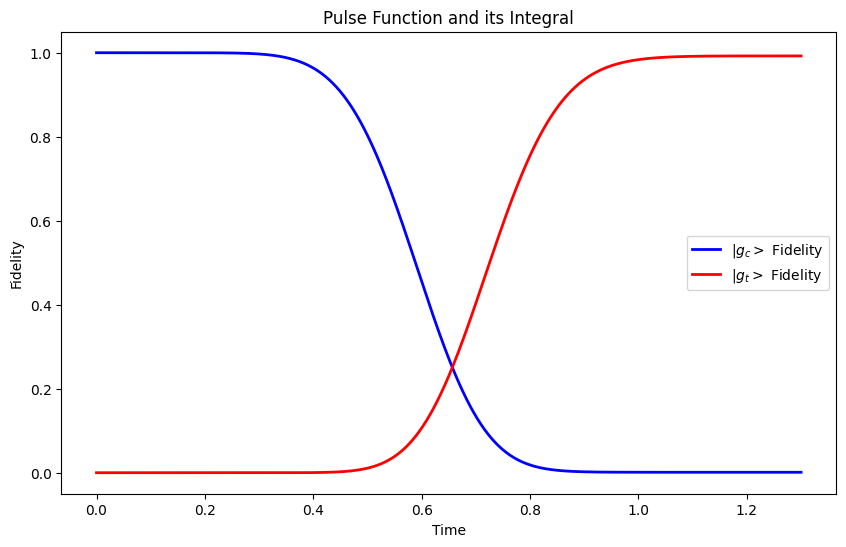

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(tlist,me.expect[2],'-b',lw=2,label='$|g_c>$ Fidelity')

plt.plot(tlist,me.expect[3],'-r',lw=2,label='$|g_t>$ Fidelity')

plt.xlabel('Time')
plt.ylabel('Fidelity')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()
plt.show()